In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Problema 1

Uma plataforma semi-submersível está sujeita apenas a forças ambientais constantes que atuam  na  direção  horizontal. Para limitar seu passeio  ela  será  ancorada através  de 2 linhas de amarração idênticas lançadas de bordos opostos da plataforma, como mostra a figura. As seguintes características das linhas e do local de ancoragem já foram definidas:

$\textbf{Linhas de Ancoragem}$
- Composição: Homogênega
- Material: Amarra R3
- Diâmetro: 76 mm
- Peso linear submerso: 0.99 kN/m
- Rigidez elástica axial: 552 MN ($\approx \infty$)
- Tração de ruptura: 4884 kN

$\textbf{Dados do Sistema de Acoragem}$
- Profundidade: 500 m
- Pré-tensão nas linhas: 1000 kN
- Comprimento total das linhas: 1000 m

In [2]:
# Dados das linhas de ancoragem
D = 0.076         # Diametro; m
w = 990           # Peso linear submerso; N/m
R = math.inf      # Rigidez elastica axial; N
T_rip = 4884e3    # Tracao de ruptura; N

# Dados do sistema de ancoragem
P = 500           # Profundidade; m
T_f = 1e6         # Pre-tensao nas linhas; N
l = 1e3           # Comprimento das linhas; m

### Exercicio 1

Para  a  posição  inicial  de  equilíbrio  (posição  neutra  da  plataforma  -  sem  forças  
ambientais) determinar:
1. Raio de ancoragem das linhas;
2. Comprimento do trecho apoiado no solo;
3. Componente horizontal (H) da tração nas linhas;
4. Ângulo das linhas com a vertical no ponto de amarração (fairlead);
5. Componente vertical (V) no ponto de amarração (fairlead).
6. Desenhar a curva das Linhas de Ancoragem 

In [3]:
# Posicao inicial de equilibrio e sem forcas ambientais atuantes
z = P
H = T_f - w*z
C_H = H/(w*P)

# 1) Raio de ancoragem
R_a = P*(l/P + C_H*math.acosh(1/C_H + 1) - math.sqrt(1 + 2*C_H))
print(f"1. Raio de ancoragem = {abs(R_a):.3f} m")

# 2) Comprimento do trecho apoiado no solo
l_s = P*math.sqrt(2*C_H + 1)
print(f"2. Comprimento apoiado no solo = {l - l_s:.3f} m")

# 3) Componente horizontal de tracao H
print(f"3. Componente horizontal de tracao H = {H/1000:.3f} kN")

# 4) Angulo das linhas com a vertical no ponto de amarracao
theta_f = math.atan(math.sqrt(2*C_H + 1)/C_H)
print(f"4. Angulo theta_f = {90 - math.degrees(theta_f):.3f}°")

# 5) Componente vertical de tracao V
V_f = w*l_s
print(f"5. Componente vertical de tracao V_f = {V_f/1000:.3f} kN")

1. Raio de ancoragem = 794.073 m
2. Comprimento apoiado no solo = 128.162 m
3. Componente horizontal de tracao H = 505.000 kN
4. Angulo theta_f = 30.331°
5. Componente vertical de tracao V_f = 863.119 kN


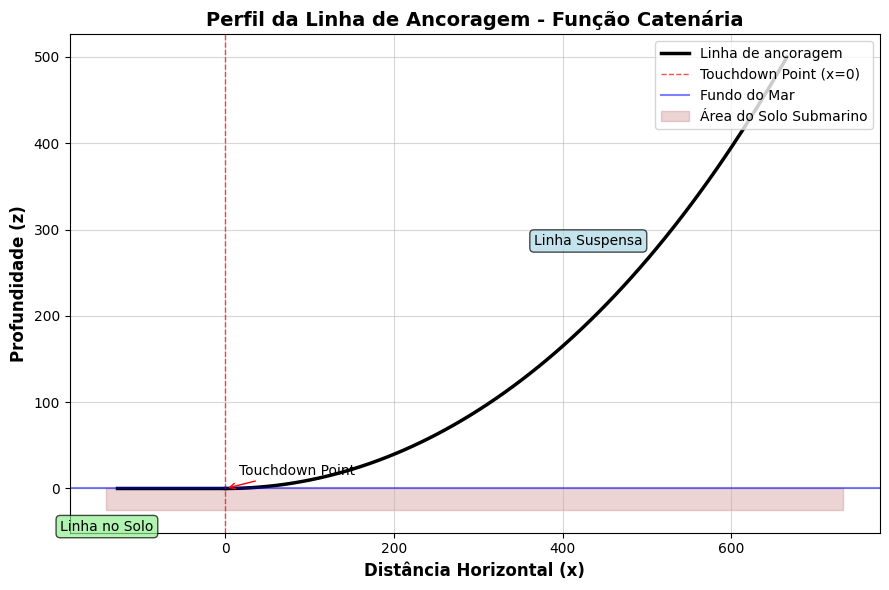

In [4]:
# 6. Desenhar a curva da linha de ancoragem
x_f = abs(R_a - l + l_s)
x = np.linspace(0, x_f, 200)
z = H/w * (np.cosh(w*x/H) - 1)

# Criar figura com tamanho personalizado
plt.figure(figsize=(9, 6))

# Plotar a linha de ancoragem suspensa
plt.plot(x, z, 'k-', linewidth=2.5, label='Linha de ancoragem')

# Plotar a linha de ancoragem no solo
plt.plot([- l + l_s, 0], [0, 0], 'k-', linewidth=2.5)

# Adicionar linha vertical no ponto de touchdown
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Touchdown Point (x=0)')

# Adicionar linha horizontal representando o fundo do mar
plt.axhline(y=0, color='blue', linestyle='-', linewidth=1.5, alpha=0.5, label='Fundo do Mar')

# Adicionar sombreamento para a área do solo
z_min = min(plt.ylim()[0], -1)
plt.fill_between([(-l + l_s)*1.1, x_f*1.1], z_min, 0,
                alpha=0.2, color='brown', label='Área do Solo Submarino')


# Configurações do gráfico
plt.xlabel('Distância Horizontal (x)', fontsize=12, fontweight='bold')
plt.ylabel('Profundidade (z)', fontsize=12, fontweight='bold')
plt.title('Perfil da Linha de Ancoragem - Função Catenária', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.5)

plt.legend(loc='upper right')

#plt.xlim((-l + l_s)*1.1, x_f*1.1)
#plt.ylim(-20, max(z)*1.1)

plt.annotate('Touchdown Point', xy=(0, 0), xytext=(10, 10),
            textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate('Linha Suspensa', xy=(x_f/2, max(z)/2),
            xytext=(20, 20), textcoords='offset points', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", alpha=0.7))

plt.annotate('Linha no Solo', xy=((-l + l_s)/2, -0.5),
            xytext=(-80, -30), textcoords='offset points', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.7))

plt.tight_layout()
plt.show()

In [5]:
def validade_C_H(C_H):
    v = ((l/P)**2 - 1)/2
    #print(f"v = {v}")
    if C_H <= v:
        print("Linha em catenária completa")
        return True
    else:
        print("C_H > v; Linha em catenária parcial")
        #print(f"{C_H} > {v}")
        return False

### Exercicio 2

A  partir  da  posição  de  ancoragem  do  Item  1,  determine  qual  o  passeio  horizontal  
máximo da plataforma sem que ocorram os seguintes eventos:
1. Uplift da âncora (componente vertical deve ser nula na âncora);
2. A tração máxima nas linhas seja maior do que a tração de ruptura:
3. Superposição de material no ponto de toque no solo (“empilhamento”). 

In [6]:
# 1. Evitar uplift da ancora
# Nesse caso, o coenficiente C_H deverá ser, no máximo, igual a 1.5
C_H_min = 1.5

# Usando, agora, a Eq. (23), encontramos o raio de ancoragem maximo permitido para este caso
R_a_max_uplift = P*(l/P + C_H_min*math.acosh(1/C_H_min + 1) - math.sqrt(1 + 2*C_H_min))
passeio_a = R_a - R_a_max_uplift
print(f"1. Passeio para evitar uplift da ancora = {abs(passeio_a):.3f} m")


# 2. Evitar racao maxima maior que a tracao de ruptura
# Combinando as equacoes (25) e (26), podemos calular o C_H_max
C_H_max = T_rip/(w*P) - 1

# Validando o valor de C_H_max
print("2. ", end='')
validade_C_H(C_H_max)


# 3. Evitar empilhamento
# Nesse caso, R_a = P - l = 500
R_a_empilhamento = 500
passeio_c = R_a - R_a_empilhamento
print(f"3. Passeio para nao gerar empilhamento = {abs(passeio_c):.3f} m")

1. Passeio para evitar uplift da ancora = 29.886 m
2. C_H > v; Linha em catenária parcial
3. Passeio para nao gerar empilhamento = 294.073 m


### Exercício 3

 A partir da posição de ancoragem do Item 1, determine qual a força ambiental máxima 
que o sistema de ancoragem equilibraria para que o passeio horizontal da plataforma não 
ultrapasse 5% da profundidade.

In [7]:
# A força ambiental em questão será igual a força horizontal de tracao da linha de ancoragem, H
def encontrar_C_H_max(R_a_max, P, l, tol=1e-6, max_iter=100):
    """
    Encontra C_H_max usando o método da secante
    """

    def f(C):
        if C <= 0 or (1/C + 1) <= 1:
            return float('inf')
        return P*(l/P + C*math.acosh(1/C + 1) - math.sqrt(1 + 2*C)) - R_a_max

    # Dois chutes iniciais
    x0, x1 = 0.1, 0.2

    for i in range(max_iter):
        f_x0 = f(x0)
        f_x1 = f(x1)

        if abs(f_x1) < tol:
            return x1

        if abs(f_x1 - f_x0) < tol:  # Evita divisão por zero
            break

        x_new = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)

        # Garantir que x_new está em domínio válido
        if x_new <= 0:
            x_new = (x0 + x1) / 2

        x0, x1 = x1, x_new

    return x1

# Passeio maximo definido para a linha encurtada
R_a_max = R_a - 0.05*P
print(f"Raio de ancoragem da linha encurtada = {R_a_max:.3f} m")

C_H_max = encontrar_C_H_max(R_a_max, P, l)
#validade_C_H(C_H_max)
#print(f"C_H_max = {C_H_max:.6f}")

# Por fim, da Eq. (27):
H_enc = C_H_max * w * P
print(f"Força horizontal na linha encurtada = {H_enc/1000:.3f} kN")
print()

# Passeio maximo definido para a linha esticada
R_a_max = R_a + 0.05*P
print(f"Raio de ancoragem da linha esticada = {R_a_max:.3f} m")

C_H_max = encontrar_C_H_max(R_a_max, P, l)
#validade_C_H(C_H_max)
#print(f"C_H_max = {C_H_max:.6f}")

# Por fim, da Eq. (27):
H_est = C_H_max * w * P
print(f"Força horizontal na linha esticada = {H_est/1000:.3f} kN")

print()
# A força ambiental será a diferença dessas duas forças
print(f"Força ambiental = {abs(H_est - H_enc)/1000:.3f} kN")

Raio de ancoragem da linha encurtada = 769.073 m
Força horizontal na linha encurtada = 373.530 kN

Raio de ancoragem da linha esticada = 819.073 m
Força horizontal na linha esticada = 695.428 kN

Força ambiental = 321.897 kN


## Problema 2

Um Riser Rígido em Catenária (SCR) vai ser instalado numa plataforma SPAR. O ponto 
de fixação do Riser na plataforma está a 1.600m de profundidade e o Raio de Ancoragem 
até a Base do Riser no solo é de 1.306,5 m.

$\textbf{Característica do riser e instalação}$
- Diâmetro externo: 0.324 m
- Espessura da parede: 0.0205 m
- Rigidez: 4.67 $\times 10^7$ Nm $^2$
- Massa unitária submersa: 100 kg/m
- Densidade do fluido interno: 840 kg/m $^3$
- Profundidade: 1600 m
- Raio de Ancoragem Ra: 1306.5 m
- Comprimento do Riser: 2333 m
- Tensão de Escoamento do Material = 450 MPa

In [8]:
# Dados ambientais
rho_i = 840       # Densidade do fluido interno; kg/m3
P = 1600          # Profundidade; m
R_a = 1306.5      # Raio de ancoragem; m

# Parametros do riser
Do = 0.324        # Diametro externo; m
t = 0.0205        # Espessura; m
EI = 4.67e7       # Rigidez a flexao; Nm2
w_i = 100*9.81    # Peso linear submerso; N/m
l = 2333          # Comprimento do riser; m
T_esc = 450e6     # Tensão de escoamento do material; Pa = N/m2

# Area transversal da linha
A = math.pi*((Do/2)**2 - (Do/2 - t)**2)
print(f"Area transversal da linha = {A:.3f} m2")

# Calculo do peso linear considerando o fluido
w = w_i + math.pi*(Do/2 - t)**2 * rho_i * 9.81
print(f"Peso linear submerso w = {w:.3f} N/m")

Area transversal da linha = 0.020 m2
Peso linear submerso w = 1499.336 N/m


### Exercício 1

Determine a configuração geométrica inicial do Riser e os esforços no ponto de fixação na plataforma.

In [9]:
# Determinacao do parametro C_H utilizando a funcao do problema 1.3
C_H = encontrar_C_H_max(R_a, P, l)


# Calculo theta
theta = math.atan(math.sqrt(2*C_H + 1)/C_H)
print(f"Angulo theta_f = {math.degrees(theta):.3f}°")   # ~77.883° -> corresponde ao que esta na figura


# Calculo de esforcos no ponto de fixacao
# Aplicando a Eq. (27), obtemos a componente horizontal da forca de fixacao
H = C_H * w * P
print(f"Forca horizontal H = {H/1000:.3f} kN")

# Para obter a o modulo da forca de fixacao:
T_f = H/math.cos(theta)
print(f"Pré-tensão nas linhas T_f = {T_f/1000:.3f} kN")

# Por fim, obter a componente vertical da forca de fixacao:
V = T_f * math.sin(theta)
print(f"Forca vertical V = {V/1000:.3f} kN")

Angulo theta_f = 77.883°
Forca horizontal H = 637.327 kN
Pré-tensão nas linhas T_f = 3036.264 kN
Forca vertical V = 2968.621 kN


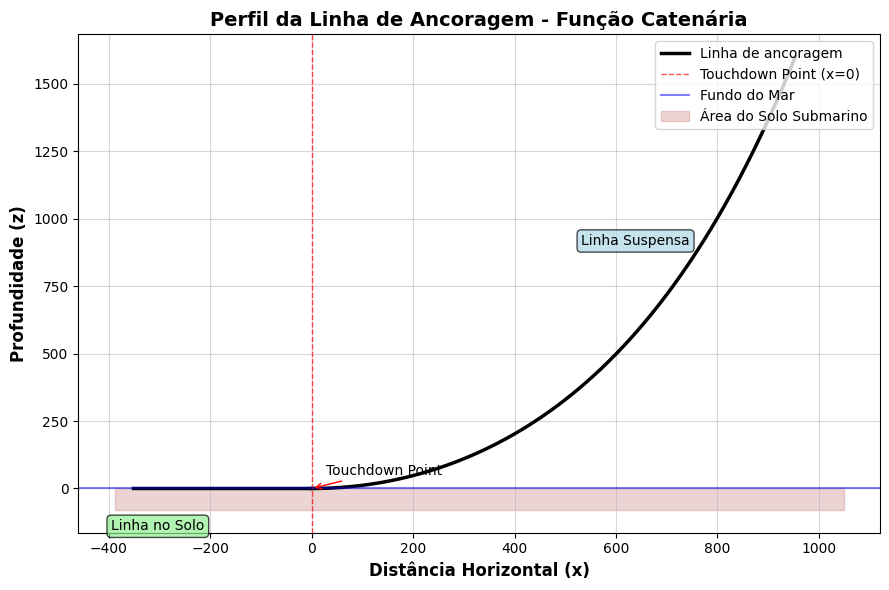

In [10]:
# Configuracao geometrica inicial: desenhar a curva da linha de ancoragem
# Para descobrir o comprimento suspenso da linha, utilizamos a Eq. (21)
l_s = P * math.sqrt(2*C_H + 1)

# Obtendo a coordenada x do touchdown point e aplicando a equacao da catenaria completa:
x_f = abs(R_a - l + l_s)
x = np.linspace(0, x_f, 200)
z = H/w * (np.cosh(w*x/H) - 1)

# Criar figura com tamanho personalizado
plt.figure(figsize=(9, 6))

# Plotar a linha de ancoragem suspensa
plt.plot(x, z, 'k-', linewidth=2.5, label='Linha de ancoragem')

# Plotar a linha de ancoragem no solo
plt.plot([- l + l_s, 0], [0, 0], 'k-', linewidth=2.5)

# Adicionar linha vertical no ponto de touchdown
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Touchdown Point (x=0)')

# Adicionar linha horizontal representando o fundo do mar
plt.axhline(y=0, color='blue', linestyle='-', linewidth=1.5, alpha=0.5, label='Fundo do Mar')

# Adicionar sombreamento para a área do solo
z_min = min(plt.ylim()[0], -1)
plt.fill_between([(-l + l_s)*1.1, x_f*1.1], z_min, 0,
                alpha=0.2, color='brown', label='Área do Solo Submarino')


# Configurações do gráfico
plt.xlabel('Distância Horizontal (x)', fontsize=12, fontweight='bold')
plt.ylabel('Profundidade (z)', fontsize=12, fontweight='bold')
plt.title('Perfil da Linha de Ancoragem - Função Catenária', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.5)

plt.legend(loc='upper right')

#plt.xlim((-l + l_s)*1.1, x_f*1.1)
#plt.ylim(-20, max(z)*1.1)

plt.annotate('Touchdown Point', xy=(0, 0), xytext=(10, 10),
            textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate('Linha Suspensa', xy=(x_f/2, max(z)/2),
            xytext=(20, 20), textcoords='offset points', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", alpha=0.7))

plt.annotate('Linha no Solo', xy=((-l + l_s)/2, -0.5),
            xytext=(-80, -30), textcoords='offset points', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.7))

plt.tight_layout()
plt.show()

### Exercício 2

Determine o valor do coeficiente de segurança em relação à tensão de escoamento do 
material depois de uma deriva igual a 10% da profundidade e de um movimento de heave 
de amplitude igual a 5 metros

In [11]:
# Refazendo o Exercício 1 com os novos parametros
R_a += 0.1*P ;P += 5

# Determinacao do parametro C_H utilizando a funcao do problema 1.3
C_H = encontrar_C_H_max(R_a, P, l)

# Calculo theta
theta = math.atan(math.sqrt(2*C_H + 1)/C_H)

# Calculo de esforcos no ponto de fixacao
# # Para obter a o modulo da forca de fixacao, aplicando a Eq. (27):
T_f = (C_H * w * P)/math.cos(theta)# - 5e5
print(f"Pré-tensão nas linhas T_f = {T_f/1000:.3f} kN")

# Coenficiente de segurança
C_s = (A*T_esc)/T_f
print(f"Coeficiente de segurança C_s = {C_s:.3f}")

Pré-tensão nas linhas T_f = 3562.052 kN
Coeficiente de segurança C_s = 2.469
